In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

In [3]:
ds = xr.concat(datasets, dim='station')

# Bimonthly - select highest every 2 months
for independence

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 295
CSV_OUT = "gev_fit_scores.csv"
N_CLUSTERS = 3  # change if you want more/less clusters

if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if residual isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

# Helper to get the time dimension for a single-station DataArray
def _time_dim(da):
    # assume one non-station dimension is time
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

# Goodness-of-fit helpers
def kuiper_statistic(x, cdf_func):
    """
    Kuiper statistic V = D+ + D-
    x: 1D array of samples
    cdf_func: function mapping x -> F(x)
    """
    x = np.sort(np.asarray(x))
    n = x.size
    # empirical CDF points: i/n at each x_i
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)

    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    """
    R² between empirical CDF and model CDF.
    """
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)  # slightly less extreme than i/n
    F_mod = cdf_func(x)

    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

results = []

for s in stations:
    # DataArray for this station
    da = ds[TARGET_VAR].sel(station=s)

    # infer time dimension
    tdim = _time_dim(da)

    # drop NaNs/infs
    da = da.where(np.isfinite(da), drop=True)

    # require at least some data
    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # bimonthly maxima (2-month block maxima)
    # requires datetime-like index on the time dimension
    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    # Fit GEV: params = (c, loc, scale)
    gev_params = st.genextreme.fit(x)
    c, loc, scale = gev_params

    # CDF function for this fitted GEV
    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    # K-S statistic
    ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)

    # Kuiper statistic
    kuiper = kuiper_statistic(x, gev_cdf)

    # R² between empirical CDF and model CDF
    r2 = r2_cdf_fit(x, gev_cdf)

    lat, lon = _meta_for_station(s)

    results.append(
        {
            "station": int(s),
            "lat": lat,
            "lon": lon,
            "n_blocks": int(x.size),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "kuiper": kuiper,
            "r2_cdf": r2,
        }
    )

# Convert to DataFrame and save CSV
df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 110: not enough data after cleaning.
Skipping station 112: not enough data after cleaning.
Skipping station 113: not enough data after cleaning.


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 143: not enough data after cleaning.
Skipping station 145: not enough data after cleaning.


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

...

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 557: not enough data after cleaning.
Skipping station 558: not enough data after cleaning.
Skipping station 564: not enough data after cleaning.


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 96: not enough data after cleaning.
Saved GEV fit parameters and scores to: gev_fit_scores.csv


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- after df is created (and non-empty) ---

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# 5) Choose k (either fixed or silhouette scan)
if N_CLUSTERS is None:
    k_range = range(2, 9)
    sil = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=0, n_init="auto")
        labels = km.fit_predict(Xs)
        sil[k] = silhouette_score(Xs, labels)
    best_k = max(sil, key=sil.get)
else:
    best_k = int(N_CLUSTERS)
    sil = None

# 6) Fit final KMeans
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)
print(summary)

# If you used silhouette scan, print it
if sil is not None:
    print("Silhouette scores:", sil)


Saved clustered GEV parameters to: gev_fit_scores_kmeans_gev_k3.csv
        gev_c                               gev_loc                      \
        count      mean    median       std   count      mean    median   
cluster                                                                   
0         119  0.163802  0.164194  0.153317     119  0.859283  0.869525   
1         137  0.023901  0.008884  0.237955     137  0.442578  0.454966   
2          23  0.944565  1.047943  0.248246      23  1.406631  1.493343   

                  gev_scale            ...   ks_stat           kuiper  \
              std     count      mean  ...    median       std  count   
cluster                                ...                              
0        0.199518       119  0.365067  ...  0.070121  0.030660    119   
1        0.268165       137  0.188159  ...  0.052631  0.031936    137   
2        0.380619        23  0.438632  ...  0.124655  0.066042     23   

                                      r2_c

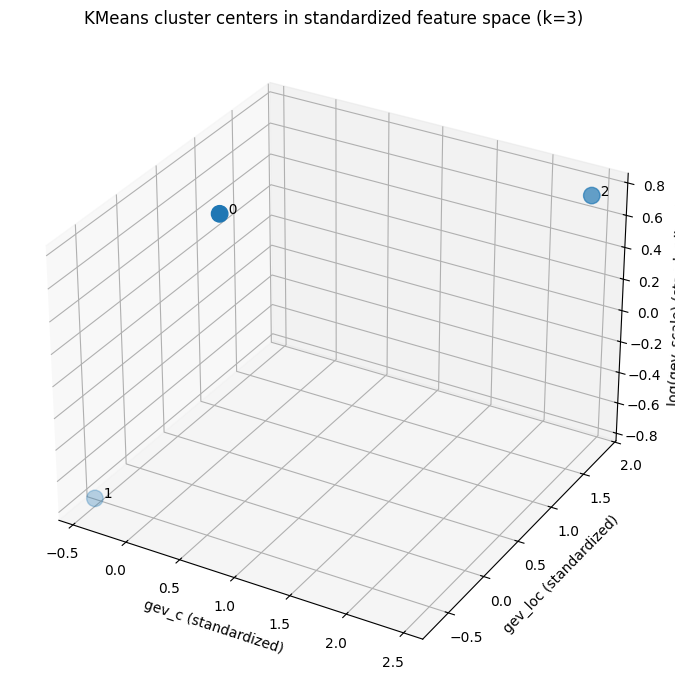

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# Feature names in the space used for clustering
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# Xdf here is the *log-transformed scale* version from your pipeline
# scaler is your fitted StandardScaler
# km is your fitted KMeans
# best_k is selected k

centers_std = km.cluster_centers_  # shape (k, 3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    centers_std[:, 0], centers_std[:, 1], centers_std[:, 2],
    s=140, marker="o", depthshade=True
)

# Label each cluster center
for i in range(centers_std.shape[0]):
    ax.text(
        centers_std[i, 0], centers_std[i, 1], centers_std[i, 2],
        f"  {i}", fontsize=10
    )

ax.set_xlabel("gev_c (standardized)")
ax.set_ylabel("gev_loc (standardized)")
ax.set_zlabel("log(gev_scale) (standardized)")
ax.set_title(f"KMeans cluster centers in standardized feature space (k={best_k})")

plt.tight_layout()
plt.show()


In [55]:
import numpy as np
import pandas as pd

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

# Keep only station + cluster label from the GEV table
label_df = GEV_clusters[["station", "cluster"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))


Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_41672/187876623.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


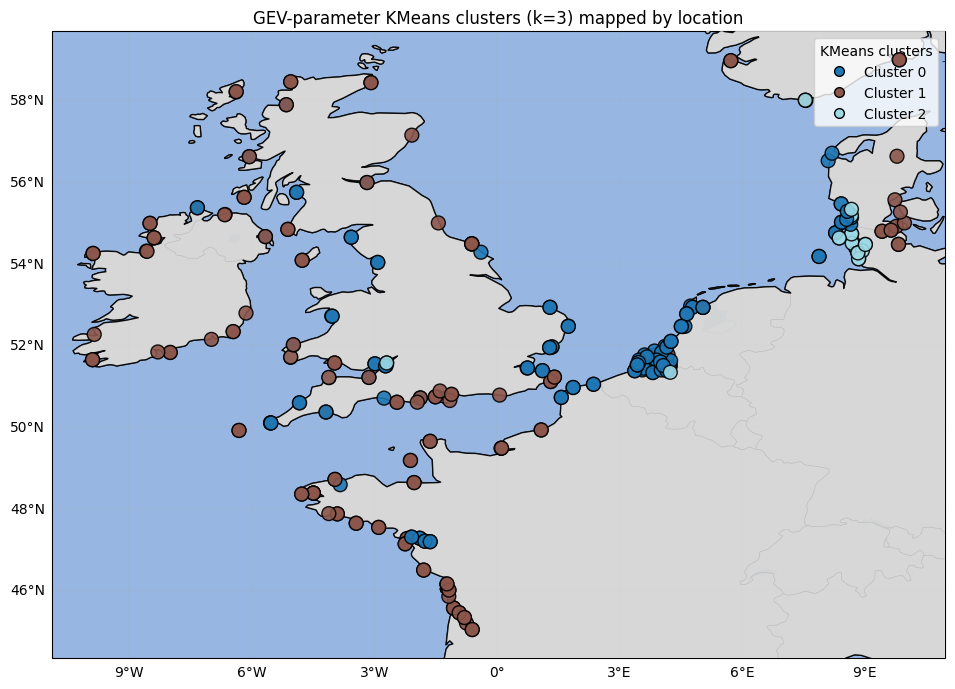

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]
ax.legend(handles=handles, title="KMeans clusters", loc="upper right", frameon=True)
# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=40,
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
plt.tight_layout()
plt.show()


In [51]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")

In [52]:
stats_df

,station,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,...,residual_is_deviant__count,residual_is_deviant__missing_frac,residual_is_deviant__annmax_mean,residual_is_deviant__annmax_std,residual_is_deviant__annmax_min,residual_is_deviant__annmax_max,residual_is_deviant__annmean_mean,residual_is_deviant__annmean_std,residual_is_deviant__annmean_min,residual_is_deviant__annmean_max
0,1,1.435309,5.204763,-16.211533,26.093597,1.500458,-6.847014,10.088026,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
1,10,1.033226,4.597254,-15.020645,23.730011,0.919975,-6.038169,8.888404,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
2,102,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
3,103,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,750192,0.0,0.127907,0.333986,0,1,0.008964,0.039935,0.0,0.241667
4,104,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,750192,0.0,0.069767,0.254755,0,1,0.002223,0.014116,0.0,0.104736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,94,1.017265,4.200128,-13.300308,19.863937,0.958878,-5.435812,8.052494,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
291,95,1.408155,5.313808,-16.098816,22.026306,1.785545,-7.461143,9.700240,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
292,96,1.017265,4.200128,-13.300308,19.863937,0.958878,-5.435812,8.052494,750192,0.0,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
293,97,1.463534,5.589287,-16.075241,26.132431,1.500534,-7.341267,10.628401,750192,0.0,...,750192,0.0,0.023256,0.150715,0,1,0.000023,0.000175,0.0,0.001598


In [6]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- after df is created (and non-empty) ---

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# 5) Choose k (either fixed or silhouette scan)
if N_CLUSTERS is None:
    k_range = range(2, 9)
    sil = {}
    for k in k_range:
        km_tmp = KMeans(n_clusters=k, random_state=0, n_init="auto")
        labels_tmp = km_tmp.fit_predict(Xs)
        sil[k] = silhouette_score(Xs, labels_tmp)
    best_k = max(sil, key=sil.get)
else:
    best_k = int(N_CLUSTERS)
    sil = None

# 6) Fit final KMeans (produces labels needed for LDA)
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels

# =========================
# 8) Fit LDA on GEV space
# =========================
lda = LinearDiscriminantAnalysis(solver="svd")
X_lda = lda.fit_transform(Xs, labels)
# X_lda has shape (n_samples, n_components) where n_components = min(k-1, n_features)

# Add LD scores to dfc
for j in range(X_lda.shape[1]):
    dfc[f"LD{j+1}"] = X_lda[:, j]

# Optional: LDA loadings / separation weights in original feature names
# (scalings_ maps features -> LD axes in standardized space)
lda_loadings = pd.DataFrame(
    lda.scalings_,
    index=feat_cols,
    columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])]
)

print("LDA separation loadings (GEV feature space):")
print(lda_loadings.sort_values("LD1", key=lambda s: s.abs(), ascending=False))

# 9) Save clustered table (now includes LD axes)
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}_lda.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered + LDA table to: {CSV_OUT_CLUSTERED}")

# 10) Quick cluster summaries (original units; note gev_scale in dfc is ORIGINAL unless you overwrote it)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)
print(summary)

# If you used silhouette scan, print it
if sil is not None:
    print("Silhouette scores:", sil)


LDA separation loadings (GEV feature space):
                LD1       LD2
gev_loc   -0.962877  0.344443
gev_scale -0.909134  0.910335
gev_c     -0.624007 -1.304209
Saved clustered + LDA table to: gev_fit_scores_kmeans_gev_k3_lda.csv
        gev_c                               gev_loc                      \
        count      mean    median       std   count      mean    median   
cluster                                                                   
0         119  0.163802  0.164194  0.153317     119  0.859283  0.869525   
1         137  0.023901  0.008884  0.237955     137  0.442578  0.454966   
2          23  0.944565  1.047943  0.248246      23  1.406631  1.493343   

                  gev_scale            ...   ks_stat           kuiper  \
              std     count      mean  ...    median       std  count   
cluster                                ...                              
0        0.199518       119  0.365067  ...  0.070121  0.030660    119   
1        0.268165      

In [22]:
summary.columns

MultiIndex([(    'gev_c',  'count'),
            (    'gev_c',   'mean'),
            (    'gev_c', 'median'),
            (    'gev_c',    'std'),
            (  'gev_loc',  'count'),
            (  'gev_loc',   'mean'),
            (  'gev_loc', 'median'),
            (  'gev_loc',    'std'),
            ('gev_scale',  'count'),
            ('gev_scale',   'mean'),
            ('gev_scale', 'median'),
            ('gev_scale',    'std'),
            ( 'n_blocks',  'count'),
            ( 'n_blocks',   'mean'),
            ( 'n_blocks', 'median'),
            ( 'n_blocks',    'std'),
            (  'ks_stat',  'count'),
            (  'ks_stat',   'mean'),
            (  'ks_stat', 'median'),
            (  'ks_stat',    'std'),
            (   'kuiper',  'count'),
            (   'kuiper',   'mean'),
            (   'kuiper', 'median'),
            (   'kuiper',    'std'),
            (   'r2_cdf',  'count'),
            (   'r2_cdf',   'mean'),
            (   'r2_cdf', 'median'),
 

In [8]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

# Keep only station + cluster label from the GEV table
label_df = GEV_clusters[["station", "cluster"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))


Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [9]:
# dfc contains: station, gev params, cluster, LD1, LD2, ...
# model_df contains: station, meteorology, cluster, ...

# Merge on station
sep_df = (
    dfc[["station", "cluster"] + [c for c in dfc.columns if c.startswith("LD")]]
    .merge(model_df, on="station", suffixes=("", "_met"))
)

# Drop duplicate cluster column if present
if "cluster_met" in sep_df.columns:
    sep_df = sep_df.drop(columns=["cluster_met"])

# Identify meteorological feature columns
id_cols = ["station", "cluster"] + [c for c in sep_df.columns if c.startswith("LD")]
met_cols = [c for c in sep_df.columns if c not in id_cols]


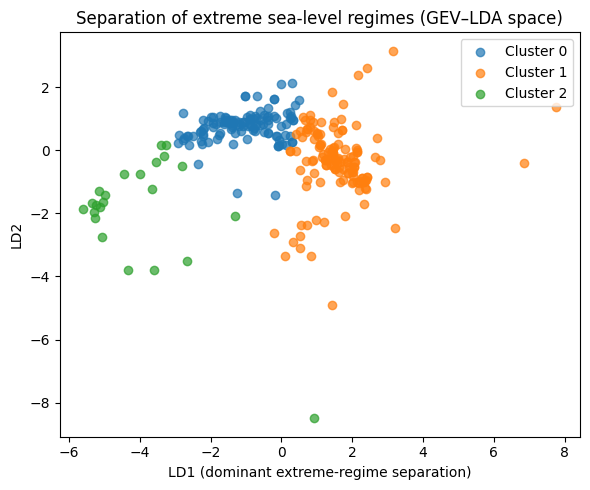

In [10]:
import matplotlib.pyplot as plt
import numpy as np

if "LD2" in sep_df.columns:
    plt.figure(figsize=(6,5))
    for c in sorted(sep_df["cluster"].unique()):
        sub = sep_df[sep_df["cluster"] == c]
        plt.scatter(sub["LD1"], sub["LD2"], label=f"Cluster {c}", alpha=0.7)
    plt.xlabel("LD1 (dominant extreme-regime separation)")
    plt.ylabel("LD2")
    plt.title("Separation of extreme sea-level regimes (GEV–LDA space)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6,4))
    for c in sorted(sep_df["cluster"].unique()):
        sub = sep_df[sep_df["cluster"] == c]
        plt.scatter(sub["LD1"], np.zeros(len(sub)), label=f"Cluster {c}", alpha=0.7)
    plt.xlabel("LD1 (dominant extreme-regime separation)")
    plt.yticks([])
    plt.title("Extreme-regime separation (single LDA axis)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [23]:
sep_df

,station,cluster,LD1,LD2,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,...,residual_is_deviant__count,residual_is_deviant__missing_frac,residual_is_deviant__annmax_mean,residual_is_deviant__annmax_std,residual_is_deviant__annmax_min,residual_is_deviant__annmax_max,residual_is_deviant__annmean_mean,residual_is_deviant__annmean_std,residual_is_deviant__annmean_min,residual_is_deviant__annmean_max
0,1,1,2.022488,-0.690657,1.435309,5.204763,-16.211533,26.093597,1.500458,-6.847014,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
1,10,1,1.418570,-0.023920,1.033226,4.597254,-15.020645,23.730011,0.919975,-6.038169,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
2,102,1,2.189721,-1.270921,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
3,103,0,0.139145,0.177039,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,...,750192,0.0,0.127907,0.333986,0,1,0.008964,0.039935,0.0,0.241667
4,104,0,-0.069610,0.336143,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,...,750192,0.0,0.069767,0.254755,0,1,0.002223,0.014116,0.0,0.104736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,1,0.243237,-0.008878,1.321126,4.322766,-13.039688,18.429459,1.281563,-5.325874,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
275,94,1,1.008608,0.530501,1.017265,4.200128,-13.300308,19.863937,0.958878,-5.435812,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
276,95,1,1.890110,-0.733320,1.408155,5.313808,-16.098816,22.026306,1.785545,-7.461143,...,750192,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000
277,97,1,1.641593,-0.369805,1.463534,5.589287,-16.075241,26.132431,1.500534,-7.341267,...,750192,0.0,0.023256,0.150715,0,1,0.000023,0.000175,0.0,0.001598


In [30]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# 1) Keep only numeric meteorological columns
X_met = sep_df[met_cols].apply(pd.to_numeric, errors="coerce")
X_met = X_met.drop(columns=[c for c in cols_to_drop if c in X_met .columns])

# 2) Replace inf with NaN
X_met = X_met.replace([np.inf, -np.inf], np.nan)

# 3) Drop columns that are completely missing
all_nan_cols = X_met.columns[X_met.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols[:10], "..." if len(all_nan_cols) > 10 else "")
    X_met = X_met.drop(columns=all_nan_cols)

# 4) Impute remaining NaNs (median)
imputer = SimpleImputer(strategy="median")
X_met_imp = imputer.fit_transform(X_met)

# Response
y_sep = sep_df["LD1"].astype(float).values

R²: 0.5697238796217424


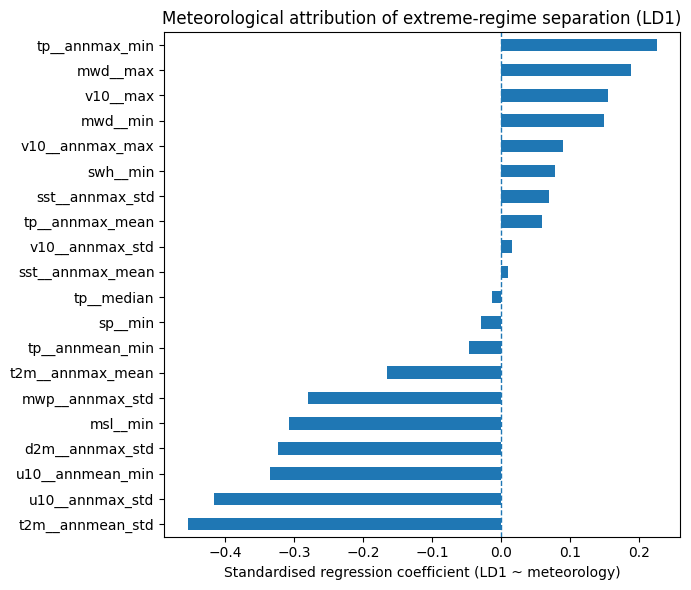

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

pipe_sep = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=10000))
])

pipe_sep.fit(X_met_imp, y_sep)

sep_coef = pd.Series(pipe_sep.named_steps["lasso"].coef_, index=X_met.columns)
sep_coef = sep_coef[sep_coef != 0].sort_values(key=lambda s: s.abs(), ascending=False)

print("R²:", pipe_sep.score(X_met_imp, y_sep))
import matplotlib.pyplot as plt

top = sep_coef.head(20).sort_values()

plt.figure(figsize=(7, 6))
top.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Standardised regression coefficient (LD1 ~ meteorology)")
plt.title("Meteorological attribution of extreme-regime separation (LD1)")
plt.tight_layout()
plt.show()


In [19]:
print("Any NaNs after imputation?", np.isnan(X_met_imp).any())
print("Any infs after imputation?", np.isinf(X_met_imp).any())
print("X_met shape:", X_met.shape)


Any NaNs after imputation? False
Any infs after imputation? False
X_met shape: (279, 255)


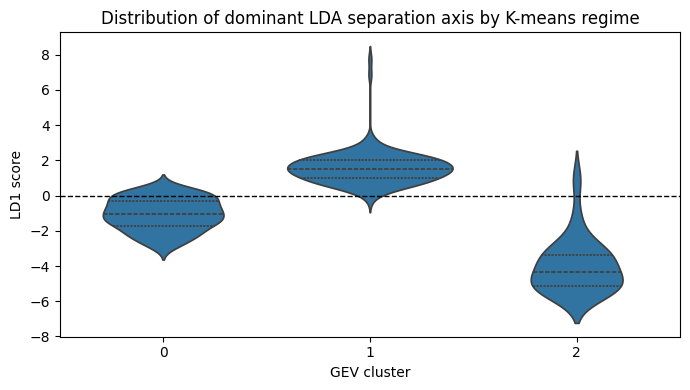

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.violinplot(data=dfc, x="cluster", y="LD1", inner="quartile")
plt.axhline(0, color="k", lw=1, ls="--")
plt.title("Distribution of dominant LDA separation axis by K-means regime")
plt.xlabel("GEV cluster")
plt.ylabel("LD1 score")
plt.tight_layout()
plt.show()

In [33]:
# K-means centroids in standardized GEV space
centroids = km.cluster_centers_

# Project into LDA space
centroids_lda = lda.transform(centroids)

centroids_lda = pd.DataFrame(
    centroids_lda,
    columns=[f"LD{i+1}" for i in range(centroids_lda.shape[1])]
)
centroids_lda["cluster"] = range(best_k)

centroids_lda


,LD1,LD2,cluster
0,-1.052048,0.770232,0
1,1.582696,-0.352386,1
2,-3.984156,-1.886121,2


In [34]:
# Between/within scatter ratio for LD1
lda.explained_variance_ratio_


array([0.83214768, 0.16785232])

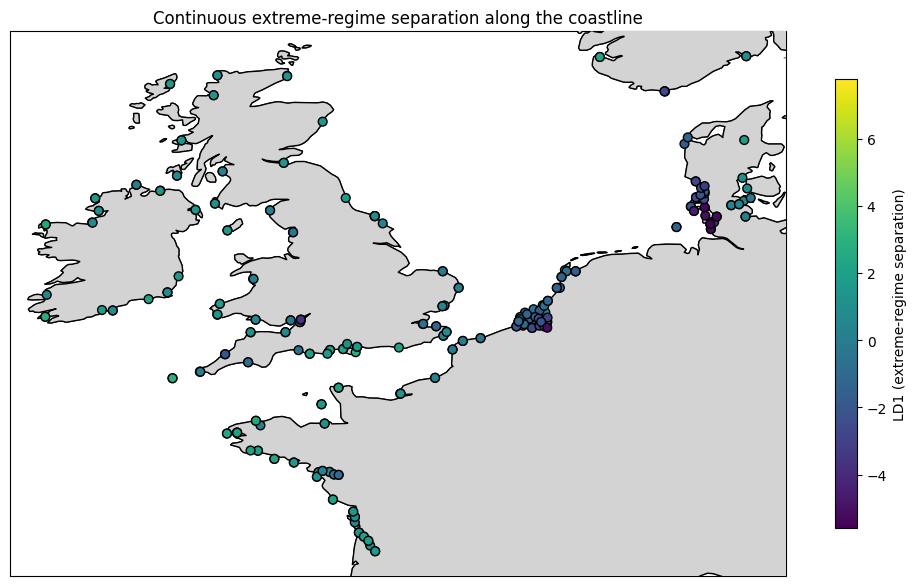

In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example projection (PlateCarree is appropriate for lon/lat data)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)


# Add land on top
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m",
    facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, zorder=3)

# Optional contextual layers
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=0)

# Plot your data
sc = ax.scatter(
    dfc["lon"], dfc["lat"],
    c=dfc["LD1"],
    cmap="viridis",
    s=40,
    transform=ccrs.PlateCarree(),
    zorder=4,
    edgecolors='black'
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8)
cbar.set_label("LD1 (extreme-regime separation)")

ax.set_title("Continuous extreme-regime separation along the coastline")

plt.tight_layout()
plt.show()


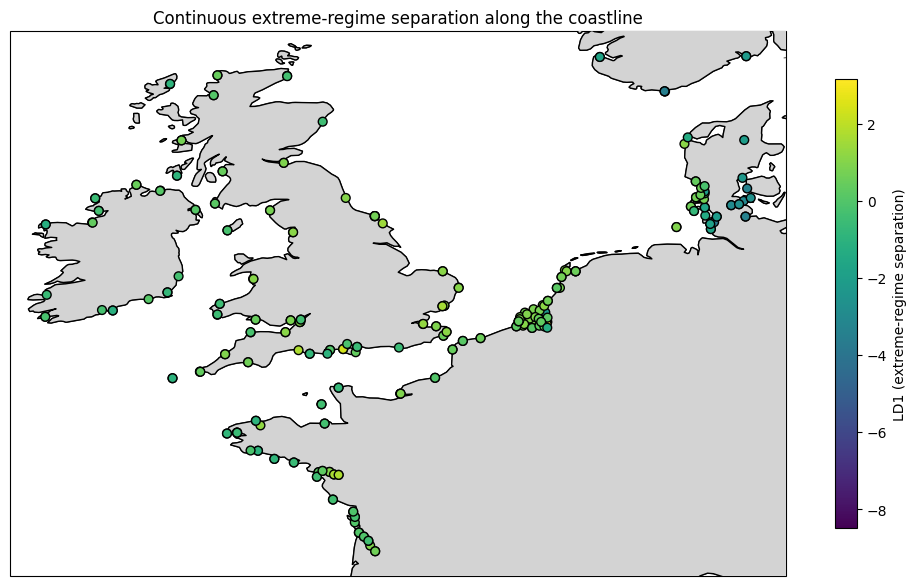

In [43]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example projection (PlateCarree is appropriate for lon/lat data)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)


# Add land on top
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m",
    facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, zorder=3)

# Optional contextual layers
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=0)

# Plot your data
sc = ax.scatter(
    dfc["lon"], dfc["lat"],
    c=dfc["LD2"],
    cmap="viridis",
    s=40,
    transform=ccrs.PlateCarree(),
    zorder=4,
    edgecolors='black'
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8)
cbar.set_label("LD1 (extreme-regime separation)")

ax.set_title("Continuous extreme-regime separation along the coastline")

plt.tight_layout()
plt.show()

R²: 0.34616030842365475


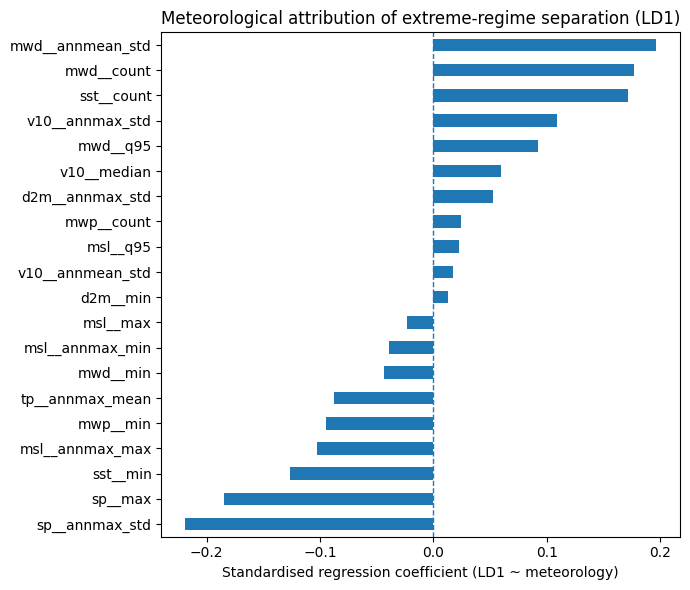

In [31]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# 1) Keep only numeric meteorological columns
X_met = sep_df[met_cols].apply(pd.to_numeric, errors="coerce")
X_met = X_met.drop(columns=[c for c in cols_to_drop if c in X_met .columns])

# 2) Replace inf with NaN
X_met = X_met.replace([np.inf, -np.inf], np.nan)

# 3) Drop columns that are completely missing
all_nan_cols = X_met.columns[X_met.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols[:10], "..." if len(all_nan_cols) > 10 else "")
    X_met = X_met.drop(columns=all_nan_cols)

# 4) Impute remaining NaNs (median)
imputer = SimpleImputer(strategy="median")
X_met_imp = imputer.fit_transform(X_met)

# Response
y_sep = sep_df["LD2"].astype(float).values
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

pipe_sep = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=10000))
])

pipe_sep.fit(X_met_imp, y_sep)

sep_coef = pd.Series(pipe_sep.named_steps["lasso"].coef_, index=X_met.columns)
sep_coef = sep_coef[sep_coef != 0].sort_values(key=lambda s: s.abs(), ascending=False)

print("R²:", pipe_sep.score(X_met_imp, y_sep))
import matplotlib.pyplot as plt

top = sep_coef.head(20).sort_values()

plt.figure(figsize=(7, 6))
top.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Standardised regression coefficient (LD1 ~ meteorology)")
plt.title("Meteorological attribution of extreme-regime separation (LD1)")
plt.tight_layout()
plt.show()



In [14]:
pipe_sep = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=10000))
])

pipe_sep.fit(X_met, y_sep)

sep_coef = pd.Series(
    pipe_sep.named_steps["lasso"].coef_,
    index=met_cols
)

sep_coef = sep_coef[sep_coef != 0].sort_values(key=lambda s: s.abs(), ascending=False)
sep_coef.head(20)


ValueError: Input X contains NaN.
Lasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_68344/3195817003.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_clusters)


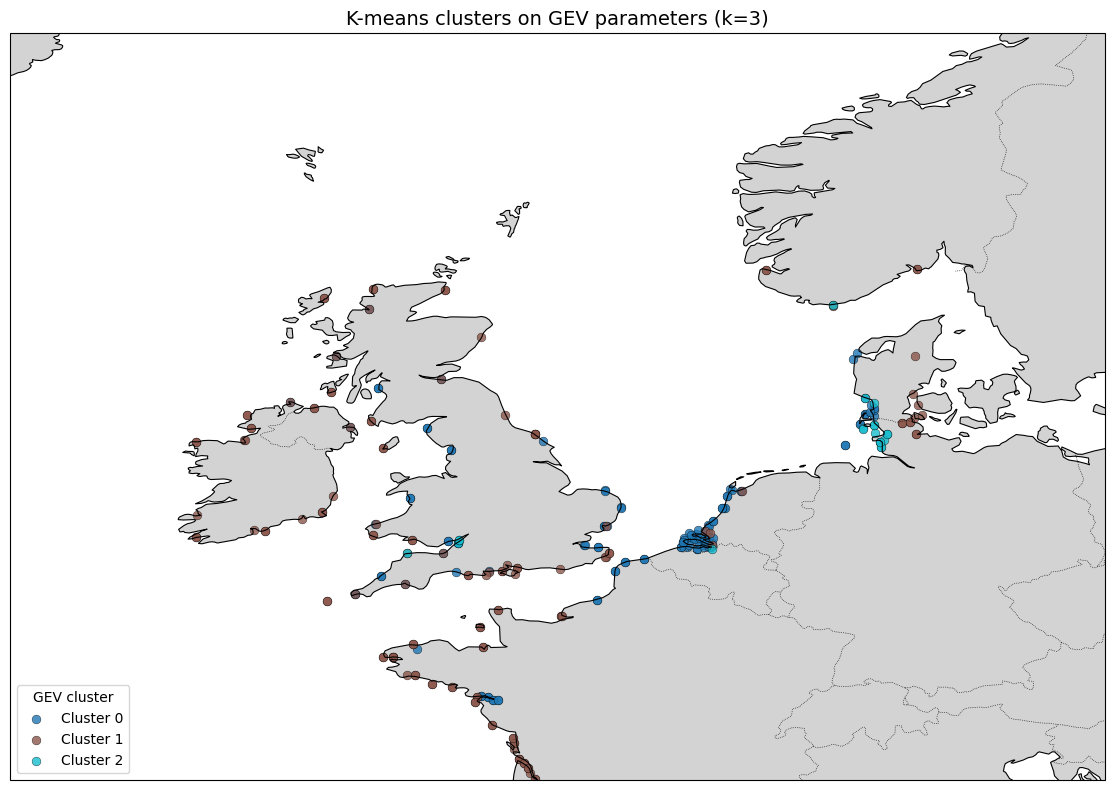

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- config ---
PROJECTION = ccrs.PlateCarree()
FIGSIZE = (12, 8)
POINT_SIZE = 40

# Safety checks
required_cols = {"lat", "lon", "cluster"}
missing = required_cols - set(dfc.columns)
if missing:
    raise ValueError(f"Missing required columns for mapping: {missing}")

# Drop rows without coordinates
plot_df = dfc.dropna(subset=["lat", "lon", "cluster"]).copy()

clusters = np.sort(plot_df["cluster"].unique())
n_clusters = len(clusters)

# Colormap with discrete colors
cmap = plt.cm.get_cmap("tab10", n_clusters)

# --- figure ---
fig = plt.figure(figsize=FIGSIZE)
ax = plt.axes(projection=PROJECTION)

# Map features
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

# Plot each cluster separately (clean legend control)
for c in clusters:
    sub = plot_df[plot_df["cluster"] == c]
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=POINT_SIZE,
        color=cmap(c),
        transform=ccrs.PlateCarree(),
        label=f"Cluster {c}",
        alpha=0.8,
        edgecolor="k",
        linewidth=0.3,
    )

# Legend
ax.legend(
    title="GEV cluster",
    loc="lower left",
    frameon=True,
)

ax.set_extent([-15,15,45,65])

# Title
ax.set_title(
    f"K-means clusters on GEV parameters (k={n_clusters})",
    fontsize=14,
)

plt.tight_layout()
plt.show()


In [13]:
dfc

,station,lat,lon,n_blocks,gev_c,gev_loc,gev_scale,ks_stat,ks_pvalue,kuiper,r2_cdf,cluster
0,1,48.383000,-4.495000,399,0.019139,0.396665,0.154269,0.024895,9.604563e-01,0.049499,0.998840,1
1,10,45.568480,-1.061555,237,0.008840,0.396950,0.213067,0.039537,8.380715e-01,0.076210,0.996165,1
2,102,50.102000,-5.542000,377,0.091521,0.382410,0.133945,0.028702,9.063368e-01,0.053232,0.998736,1
3,103,50.103000,-5.542750,448,0.182677,0.416630,0.338177,0.198556,5.918320e-16,0.348877,0.833575,0
4,104,50.099998,-5.533330,208,0.207246,0.355758,0.397802,0.227428,6.154688e-10,0.426214,0.779586,0
...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,49.930000,1.085000,354,0.134247,0.648707,0.249021,0.032957,8.242212e-01,0.060356,0.997792,0
275,94,49.481602,0.105600,334,-0.071086,0.606402,0.217723,0.049914,3.641023e-01,0.082405,0.994583,1
276,95,49.651299,-1.635500,307,0.041510,0.421703,0.156389,0.046830,4.964226e-01,0.092796,0.994417,1
277,97,49.183300,-2.116700,194,0.001364,0.500910,0.167137,0.047496,7.555074e-01,0.083306,0.995876,1


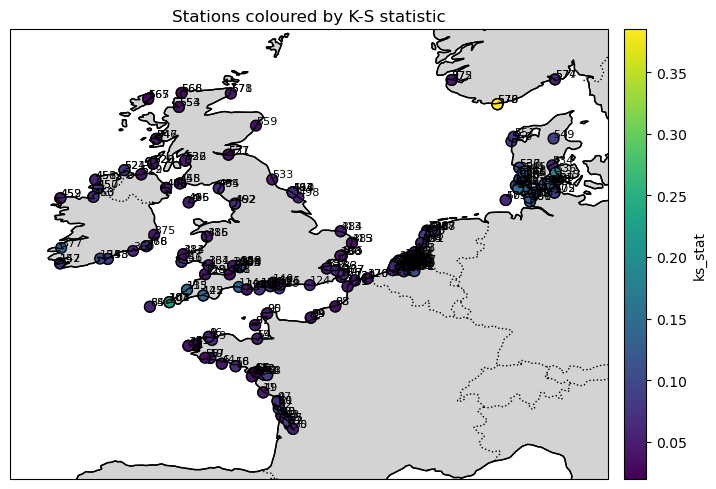

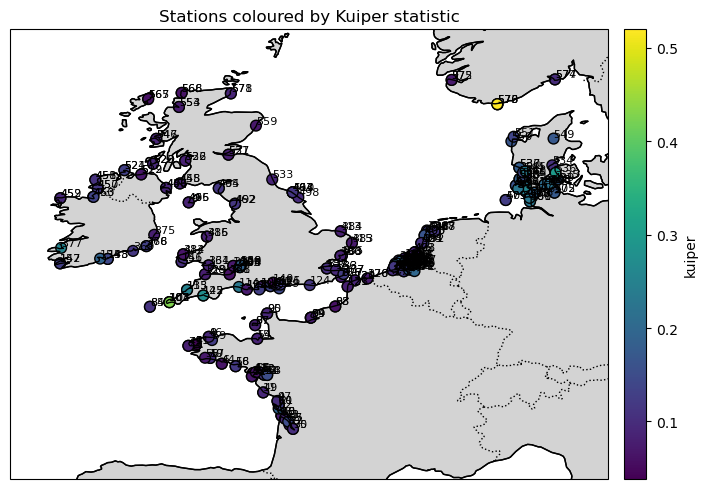

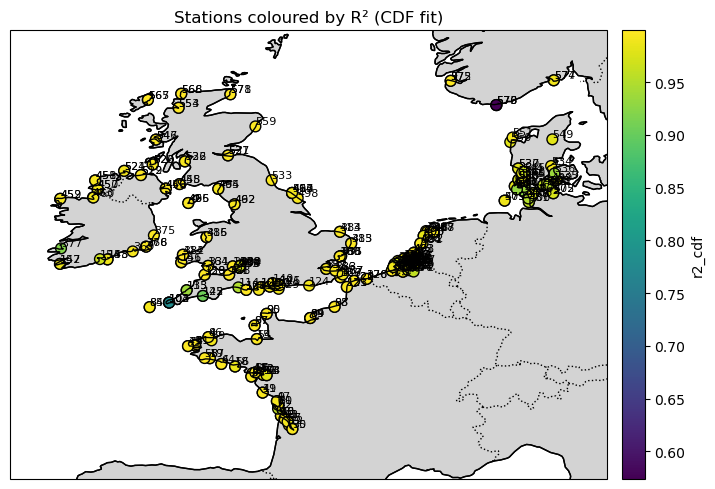

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# Drop stations without coordinates
df_map = df.dropna(subset=["lat", "lon"]).copy()

# --- helper to make a single metric map ---
def plot_metric_map(df, metric_col, title, cmap="viridis"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    # Land + coastlines
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Extent with some padding
    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    sc = ax.scatter(
        df["lon"], df["lat"],
        c=df[metric_col],
        s=60,
        transform=proj,
        cmap=cmap,
        edgecolor="k"
    )

    # station labels
    for _, row in df.iterrows():
        ax.text(
            row["lon"], row["lat"],
            str(int(row["station"])),
            transform=proj,
            fontsize=8,
            ha="left", va="bottom"
        )

    plt.title(title)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label(metric_col)
    plt.tight_layout()
    plt.show()


# --- maps coloured by KS, Kuiper, R² ---

plot_metric_map(df_map, "ks_stat", "Stations coloured by K-S statistic")
plot_metric_map(df_map, "kuiper", "Stations coloured by Kuiper statistic")
plot_metric_map(df_map, "r2_cdf", "Stations coloured by R² (CDF fit)")




k=2: silhouette score=0.6618
k=3: silhouette score=0.6270
k=4: silhouette score=0.5550
k=5: silhouette score=0.5553
k=6: silhouette score=0.5436
k=7: silhouette score=0.5296
k=8: silhouette score=0.4877


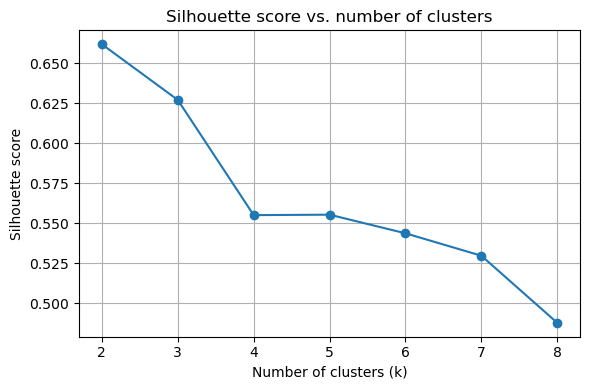

Best k by silhouette score: 2
Cluster counts with best k:
cluster
1    227
0     52
Name: count, dtype: int64


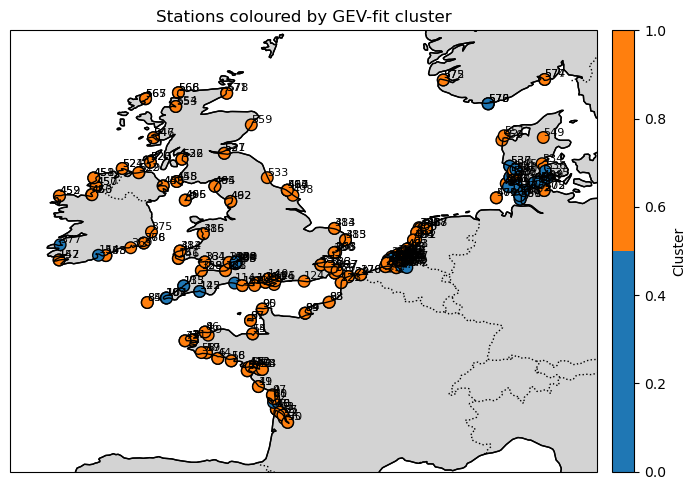

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X = df[["ks_stat", "kuiper", "r2_cdf"]].values

# Range of K to test
K_RANGE = range(2, 9)  # e.g. 2 to 8 clusters

sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k)
    sil_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")

# Plot silhouette score vs number of clusters
plt.figure(figsize=(6, 4))
plt.plot(list(K_RANGE), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs. number of clusters")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Optional: choose best k and re-cluster ---

best_k = K_RANGE[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X)
df["cluster"] = labels

print("Cluster counts with best k:")
print(df["cluster"].value_counts())

# --- map coloured by cluster (categorical) ---

from matplotlib.colors import ListedColormap

def plot_cluster_map(df, cluster_col="cluster", title="Station clusters"):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes(projection=proj)

    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    pad = 2.0
    lat_min, lat_max = df["lat"].min() - pad, df["lat"].max() + pad
    lon_min, lon_max = df["lon"].min() - pad, df["lon"].max() + pad
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Ensure cluster is int from 0..K-1
    clusters = df[cluster_col].astype(int).values
    n_clusters = len(np.unique(clusters))

    # Use a default qualitative colormap with at least n_clusters colors
    base_cmap = plt.get_cmap("tab10")
    colors = [base_cmap(i) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    sc = ax.scatter(
        df["lon"], df["lat"],
        c=clusters,
        s=70,
        transform=proj,
        cmap=cmap,
        edgecolor="k"
    )

    # station labels
    for _, row in df.iterrows():
        ax.text(
            row["lon"], row["lat"],
            str(int(row["station"])),
            transform=proj,
            fontsize=8,
            ha="left", va="bottom"
        )

    plt.title(title)
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
    cb.set_label("Cluster")
    plt.tight_layout()
    plt.show()


plot_cluster_map(df, cluster_col="cluster", title="Stations coloured by GEV-fit cluster")

In [13]:
# Ensure cluster column exists
if "cluster" not in df.columns:
    raise RuntimeError("df['cluster'] not found — run clustering first.")

# Columns to summarize
cols_to_summarize = [
    "ks_stat",
    "kuiper",
    "r2_cdf",
    "gev_c",
    "gev_loc",
    "gev_scale",
    "n_blocks"
]

# Compute cluster means
cluster_means = df.groupby("cluster")[cols_to_summarize].mean()

print("\n=== Mean Characteristics of Each Cluster ===\n")
print(cluster_means)



=== Mean Characteristics of Each Cluster ===

          ks_stat    kuiper    r2_cdf     gev_c   gev_loc  gev_scale  \
cluster                                                                
0        0.135890  0.241051  0.936277  0.455371  0.864366   0.398112   
1        0.059358  0.106123  0.991229  0.091638  0.662079   0.258176   

           n_blocks  
cluster              
0        142.480769  
1        192.083700  
